# EDA — Craigslist Used Cars

**Objectif** : exploration initiale du dataset `vehicles.csv` (~1.3 GB, ~426k lignes, 26 colonnes) pour préparer la modélisation de régression sur `price`.

Ce notebook suit le plan d'EDA défini dans `deliverables/assignment1.md` :

1. Chargement et aperçu général
2. Analyse de la variable cible `price` (distribution, outliers)
3. Analyse des valeurs manquantes (`condition`, `size`, `cylinders`…)
4. Corrélations bivariées :
   - `odometer` vs `price`
   - âge du véhicule vs `price`
   - prix médian par `manufacturer`

**Note mémoire** : le CSV brut fait 1.3 GB. On charge avec des `dtype` optimisés (categorical pour les colonnes à faible cardinalité, drop des colonnes texte/identifiants lourdes) pour rester sous ~500 MB en RAM.

## 0. Imports & configuration

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 50)

DATA_PATH = Path("..") / "data" / "vehicles.csv"
assert DATA_PATH.exists(), f"Dataset not found at {DATA_PATH.resolve()}"

## 1. Chargement du dataset

On supprime à la lecture les colonnes lourdes inutiles pour l'EDA initiale (`description` est un texte libre très volumineux, `url` / `image_url` / `VIN` / `id` n'apportent rien à l'analyse statistique).

On force des `dtype` `category` pour les colonnes catégorielles à faible cardinalité afin d'économiser de la mémoire.

In [2]:
COLS_TO_DROP = ["id", "url", "region_url", "image_url", "description", "VIN"]

CATEGORICAL_DTYPES = {
    "manufacturer": "category",
    "condition": "category",
    "cylinders": "category",
    "fuel": "category",
    "title_status": "category",
    "transmission": "category",
    "drive": "category",
    "size": "category",
    "type": "category",
    "paint_color": "category",
    "state": "category",
    "region": "category",
}

df = pd.read_csv(
    DATA_PATH,
    dtype=CATEGORICAL_DTYPES,
    parse_dates=["posting_date"],
)
df = df.drop(columns=[c for c in COLS_TO_DROP if c in df.columns])

print(f"Shape : {df.shape[0]:,} lignes x {df.shape[1]} colonnes")
print(f"Mémoire : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Shape : 426,880 lignes x 20 colonnes
Mémoire : 106.6 MB


In [3]:
df.head()

,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color,county,state,lat,long,posting_date
0,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaT
1,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaT
2,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaT
3,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaT
4,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaT


In [4]:
df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 20 columns):
 #   Column        Non-Null Count   Dtype   
---  ------        --------------   -----   
 0   region        426880 non-null  category
 1   price         426880 non-null  int64   
 2   year          425675 non-null  float64 
 3   manufacturer  409234 non-null  category
 4   model         421603 non-null  object  
 5   condition     252776 non-null  category
 6   cylinders     249202 non-null  category
 7   fuel          423867 non-null  category
 8   odometer      422480 non-null  float64 
 9   title_status  418638 non-null  category
 10  transmission  424324 non-null  category
 11  drive         296313 non-null  category
 12  size          120519 non-null  category
 13  type          334022 non-null  category
 14  paint_color   296677 non-null  category
 15  county        0 non-null       float64 
 16  state         426880 non-null  category
 17  lat           420331 non-null

## 2. Analyse de la variable cible (`price`)

On s'attend à des prix aberrants : annonces à `0 $` ("contactez-moi"), à `1 $` (clickbait), ou à des valeurs absurdes (`> 1 000 000 $`).

In [5]:
df["price"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).round(2)

count    4.268800e+05
mean     7.519903e+04
std      1.218228e+07
min      0.000000e+00
1%       0.000000e+00
5%       0.000000e+00
25%      5.900000e+03
50%      1.395000e+04
75%      2.648575e+04
95%      4.450000e+04
99%      6.699500e+04
max      3.736929e+09
Name: price, dtype: float64

In [6]:
# Comptage des prix aberrants
n = len(df)
thresholds = {
    "price == 0": (df["price"] == 0).sum(),
    "price < 100": (df["price"] < 100).sum(),
    "price < 500": (df["price"] < 500).sum(),
    "price > 100k": (df["price"] > 100_000).sum(),
    "price > 1M": (df["price"] > 1_000_000).sum(),
}
for label, count in thresholds.items():
    print(f"{label:<20} : {count:>8,} ({100 * count / n:5.2f} %)")

price == 0           :   32,895 ( 7.71 %)
price < 100          :   36,222 ( 8.49 %)
price < 500          :   42,094 ( 9.86 %)
price > 100k         :      655 ( 0.15 %)
price > 1M           :       53 ( 0.01 %)


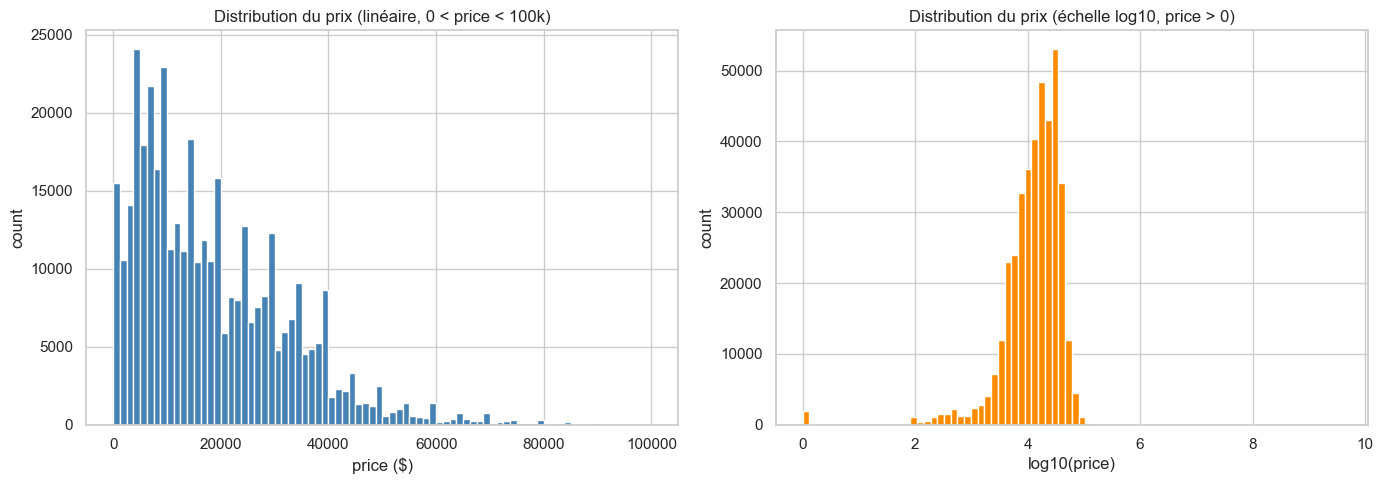

In [7]:
# Distribution des prix : échelle linéaire vs log
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mask = (df["price"] > 0) & (df["price"] < 100_000)
axes[0].hist(df.loc[mask, "price"], bins=80, color="steelblue", edgecolor="white")
axes[0].set_title("Distribution du prix (linéaire, 0 < price < 100k)")
axes[0].set_xlabel("price ($)")
axes[0].set_ylabel("count")

log_mask = df["price"] > 0
axes[1].hist(np.log10(df.loc[log_mask, "price"]), bins=80, color="darkorange", edgecolor="white")
axes[1].set_title("Distribution du prix (échelle log10, price > 0)")
axes[1].set_xlabel("log10(price)")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.show()

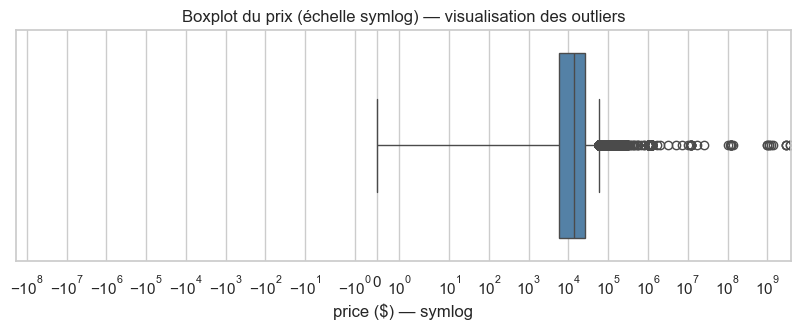

In [8]:
# Boxplot pour visualiser les outliers extrêmes
plt.figure(figsize=(10, 3))
sns.boxplot(x=df["price"], color="steelblue")
plt.xscale("symlog")
plt.title("Boxplot du prix (échelle symlog) — visualisation des outliers")
plt.xlabel("price ($) — symlog")
plt.show()

**Observations attendues** :
- Forte concentration de prix entre ~3 000 $ et ~30 000 $.
- Quantités significatives de valeurs aberrantes en bas (0 $, 1 $) et en haut (> 100 000 $).
- → Pour la modélisation : on filtrera probablement `500 <= price <= 100 000` et on testera une transformation log sur la target.

## 3. Analyse des valeurs manquantes

On regarde le taux de remplissage de chaque colonne. Sur Craigslist, on s'attend à un fort taux de NaN sur `condition`, `size`, `cylinders` (champs souvent laissés vides par les vendeurs).

In [9]:
missing = (
    pd.DataFrame({
        "n_missing": df.isna().sum(),
        "pct_missing": 100 * df.isna().mean(),
    })
    .sort_values("pct_missing", ascending=False)
)
missing.round(2)

,n_missing,pct_missing
county,426880,100.00
size,306361,71.77
cylinders,177678,41.62
condition,174104,40.79
drive,130567,30.59
paint_color,130203,30.50
type,92858,21.75
manufacturer,17646,4.13
title_status,8242,1.93
lat,6549,1.53


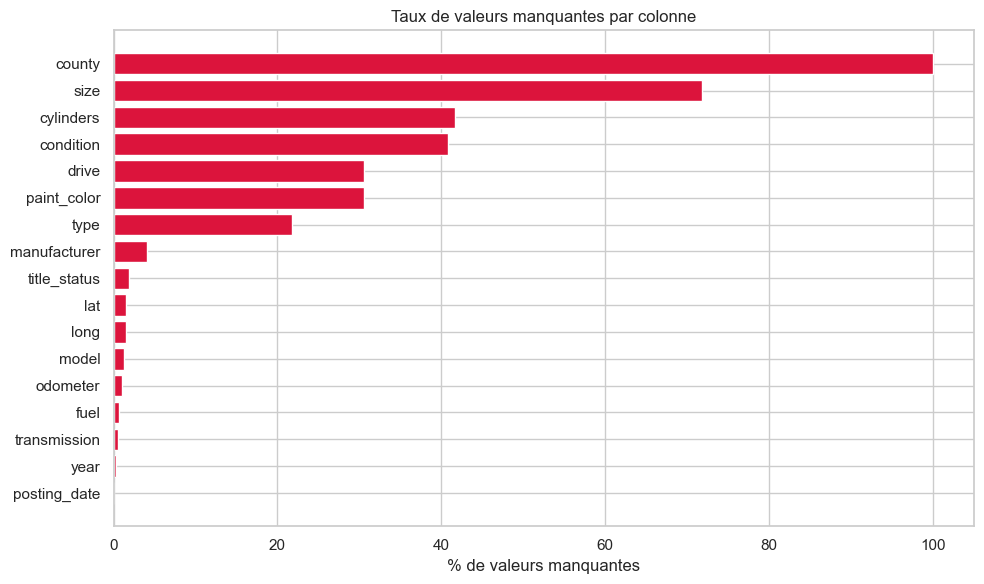

In [10]:
plt.figure(figsize=(10, 6))
missing_to_plot = missing[missing["pct_missing"] > 0].sort_values("pct_missing")
plt.barh(missing_to_plot.index, missing_to_plot["pct_missing"], color="crimson")
plt.xlabel("% de valeurs manquantes")
plt.title("Taux de valeurs manquantes par colonne")
plt.tight_layout()
plt.show()

In [11]:
# Focus sur les 3 colonnes attendues comme problématiques
for col in ["condition", "size", "cylinders"]:
    if col in df.columns:
        pct = 100 * df[col].isna().mean()
        print(f"{col:<12} : {pct:5.2f} % manquant — modalités : {df[col].value_counts(dropna=False).to_dict()}")

condition    : 40.79 % manquant — modalités : {nan: 174104, 'good': 121456, 'excellent': 101467, 'like new': 21178, 'fair': 6769, 'new': 1305, 'salvage': 601}
size         : 71.77 % manquant — modalités : {nan: 306361, 'full-size': 63465, 'mid-size': 34476, 'compact': 19384, 'sub-compact': 3194}
cylinders    : 41.62 % manquant — modalités : {nan: 177678, '6 cylinders': 94169, '4 cylinders': 77642, '8 cylinders': 72062, '5 cylinders': 1712, '10 cylinders': 1455, 'other': 1298, '3 cylinders': 655, '12 cylinders': 209}


**Décisions probables pour la suite** :
- Colonnes avec > 50 % de NaN : à imputer prudemment (catégorie `"unknown"`) ou à drop si l'apport est faible.
- Colonnes avec < 5 % de NaN : imputation simple (médiane / mode).

## 4. Corrélations bivariées

On filtre les outliers évidents pour que les graphes restent lisibles.

In [12]:
# DataFrame nettoyé pour l'EDA bivariée (sans modifier df global)
df_clean = df.loc[
    (df["price"].between(500, 100_000))
    & (df["odometer"].between(0, 400_000))
    & (df["year"].between(1980, 2022))
].copy()
df_clean["age"] = 2021 - df_clean["year"]
print(f"Lignes après filtrage outliers : {len(df_clean):,} (sur {len(df):,} initiales)")

Lignes après filtrage outliers : 371,825 (sur 426,880 initiales)


### 4.1 Impact du kilométrage (`odometer`) sur le prix

Hypothèse : relation décroissante (un kilométrage élevé fait baisser le prix).

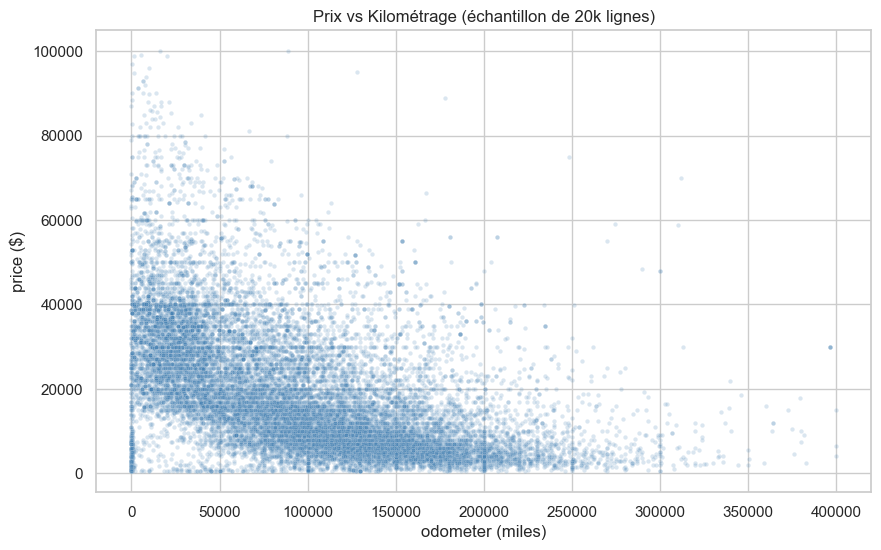

Corrélation Pearson  (price, odometer) : -0.534
Corrélation Spearman (price, odometer) : -0.610


In [13]:
sample = df_clean.sample(min(20_000, len(df_clean)), random_state=42)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=sample, x="odometer", y="price", alpha=0.2, s=10, color="steelblue")
plt.title("Prix vs Kilométrage (échantillon de 20k lignes)")
plt.xlabel("odometer (miles)")
plt.ylabel("price ($)")
plt.show()

pearson = df_clean["price"].corr(df_clean["odometer"], method="pearson")
spearman = df_clean["price"].corr(df_clean["odometer"], method="spearman")
print(f"Corrélation Pearson  (price, odometer) : {pearson:.3f}")
print(f"Corrélation Spearman (price, odometer) : {spearman:.3f}")

### 4.2 Impact de l'âge du véhicule sur le prix

Feature dérivée : `age = 2021 - year` (le dataset a été scrappé en 2021).

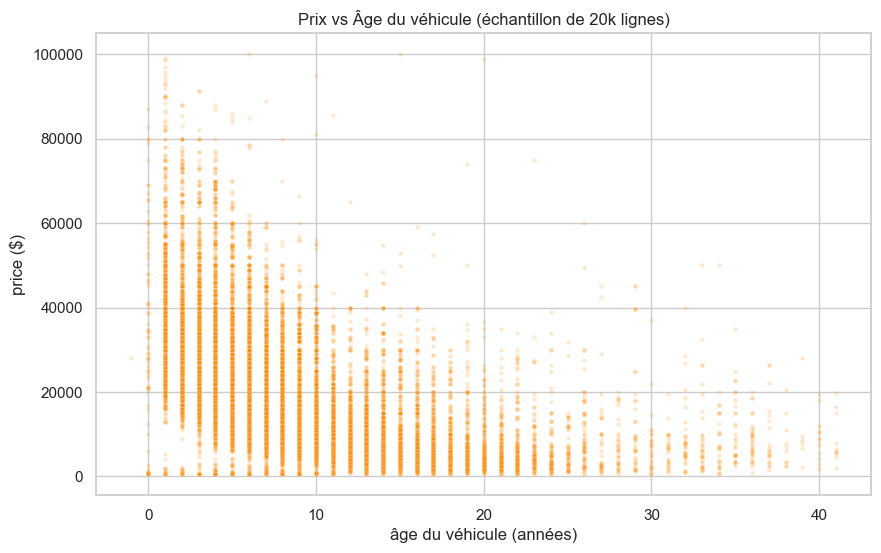

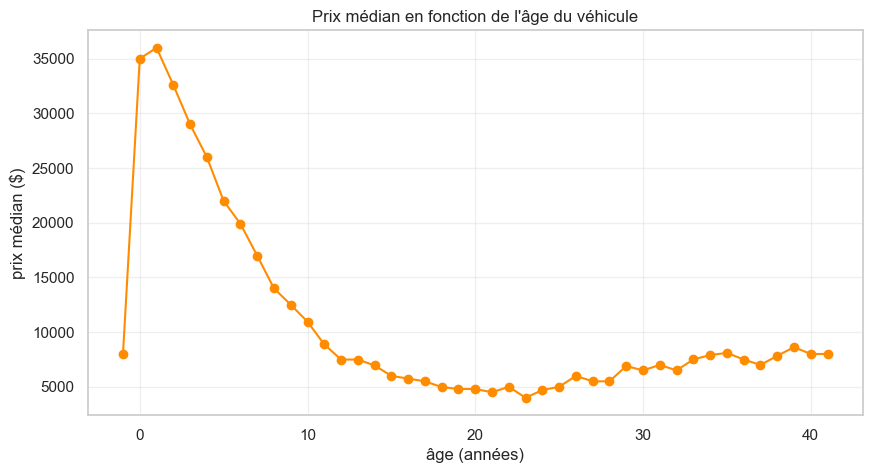

Corrélation Pearson (price, age) : -0.554


In [14]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=sample, x="age", y="price", alpha=0.2, s=10, color="darkorange")
plt.title("Prix vs Âge du véhicule (échantillon de 20k lignes)")
plt.xlabel("âge du véhicule (années)")
plt.ylabel("price ($)")
plt.show()

# Prix médian par tranche d'âge — plus lisible qu'un nuage de points
median_by_age = df_clean.groupby("age")["price"].median()
plt.figure(figsize=(10, 5))
median_by_age.plot(kind="line", marker="o", color="darkorange")
plt.title("Prix médian en fonction de l'âge du véhicule")
plt.xlabel("âge (années)")
plt.ylabel("prix médian ($)")
plt.grid(True, alpha=0.3)
plt.show()

pearson_age = df_clean["price"].corr(df_clean["age"], method="pearson")
print(f"Corrélation Pearson (price, age) : {pearson_age:.3f}")

### 4.3 Prix médian par marque (`manufacturer`)

On regarde les 20 marques les plus représentées dans le dataset, pour éviter le bruit des marques rares.

In [15]:
top20_brands = df_clean["manufacturer"].value_counts().head(20).index
by_brand = (
    df_clean[df_clean["manufacturer"].isin(top20_brands)]
    .groupby("manufacturer", observed=True)["price"]
    .agg(["median", "count"])
    .sort_values("median", ascending=False)
)
by_brand.round(0)

,median,count
manufacturer,,
ram,29995.0,16039
audi,24990.0,6953
gmc,24590.0,14910
acura,20590.0,5530
lexus,19997.0,7552
mercedes-benz,19598.0,9687
jeep,18991.0,16505
bmw,18500.0,13241
cadillac,17798.0,6295


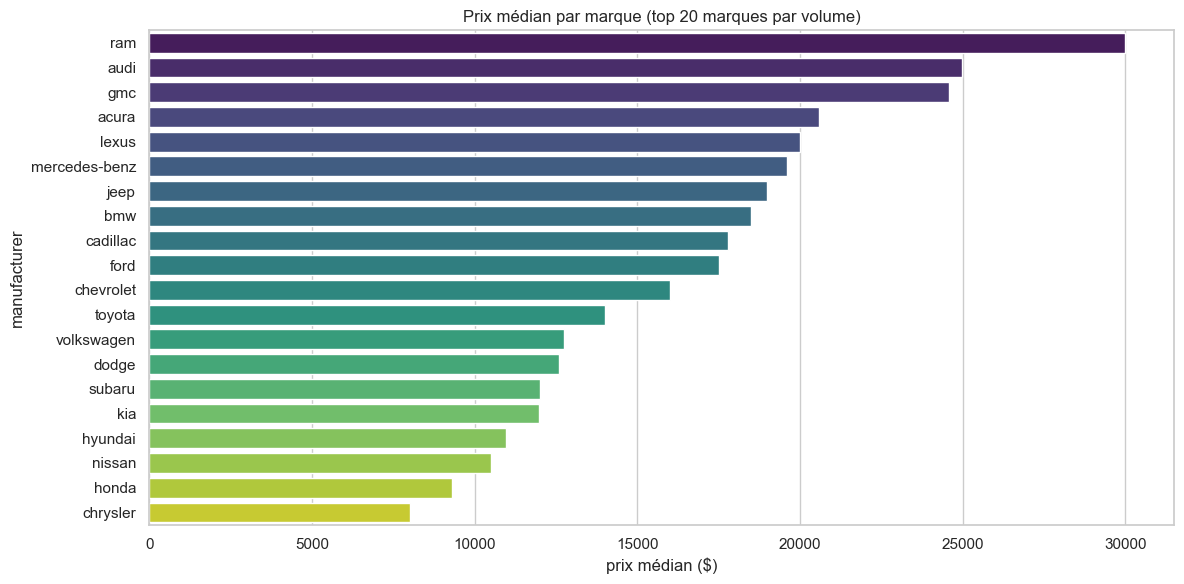

In [16]:
plt.figure(figsize=(12, 6))
sns.barplot(
    x=by_brand["median"].values,
    y=by_brand.index.astype(str),
    palette="viridis",
)
plt.title("Prix médian par marque (top 20 marques par volume)")
plt.xlabel("prix médian ($)")
plt.ylabel("manufacturer")
plt.tight_layout()
plt.show()

## 5. Synthèse & next steps

**À retenir de cet EDA initial :**

- La target `price` contient de nombreuses valeurs aberrantes (0 $, > 1 M $) — un filtrage `[500, 100 000]` paraît raisonnable.
- Plusieurs colonnes ont un fort taux de NaN (`condition`, `size`, `cylinders`) — stratégie d'imputation à définir.
- `odometer` et l'âge (`year`) sont fortement corrélés négativement avec le prix — features clés pour la régression.
- Forte hétérogénéité du prix médian selon la marque — `manufacturer` doit être encodé proprement (target encoding plutôt que one-hot vu la cardinalité de `model`).

**Prochaines étapes** (assignment 2) :
1. Pipeline de nettoyage : filtrage outliers + gestion des NaN.
2. Feature engineering : `age`, encodage des catégorielles, traitement de `posting_date`.
3. Premier baseline : régression linéaire sur features numériques uniquement.
4. Modèles avancés : `RandomForest`, `XGBoost`, `LightGBM`.
5. Comparaison MAE / RMSE et analyse des résidus.